In [1]:
# Load radargrams over David Glacier from KOPRI
# Loads MagLoResInco2 from KPDC which hopefully still has phase info.

from impdar.lib import load, plot 
import os

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

import cartopy.crs as ccrs

import segyio
import shapefile
import shapely
import xarray as xr

In [2]:
#path_MagLoResInco = '/mnt/c/users/ZacharyKatz/Desktop/KPDC/KPDC_David_IPR_2017_0028/2016-2017David/pik1/DVG/IBH0c/GL0328c/'
path_MagLoResInco = '/mnt/c/users/ZacharyKatz/Desktop/KPDC/KPDC_David_IPR_2017_0028/2016-2017David/pik1/NIS/IBH0c/Y44a/'
file_paths = [os.path.join(path_MagLoResInco, f) for f in os.listdir(path_MagLoResInco) if f.endswith('MagLoResInco2')]
path = file_paths[0]

In [3]:
raw = np.fromfile(path, dtype="<i2")

samples_per_trace=1024
scale=20000
traces = raw.size // samples_per_trace
data = raw[:traces * samples_per_trace].reshape(traces, samples_per_trace)
data = data.astype(np.float32) / scale


In [4]:
raw = np.fromfile(path, dtype='>i2')   # or >f4 if float32
print(raw[:20])

[    1 -8681     1 -7542     1 -4042     1 -4210     1 -7158     1 -8340
     1 -6198     1 -3864     2  1045     2  1682]


In [20]:
np.unique(rad_db)

array([-4.00000000e+02, -9.03087336e+01, -8.42881337e+01, ...,
        0.00000000e+00,  2.65076360e-04,             nan], shape=(32770,))

/tmp/ipykernel_6470/1879658241.py:10: RuntimeWarning: invalid value encountered in log10
  rad_db = 20 * np.log10(amp + eps)


Text(0, 0.5, 'Two-way Travel Time [usec]')

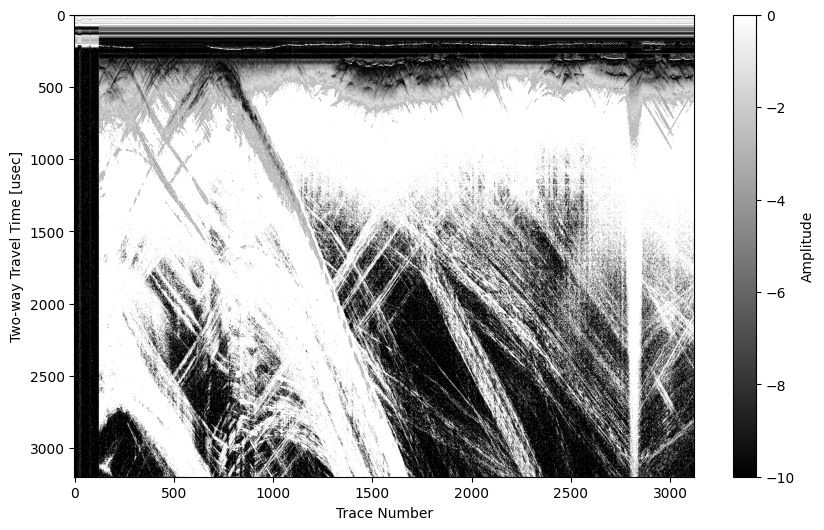

In [22]:
raw = np.fromfile(path, dtype='>i2')

channels = raw[0::2]
amps = raw[1::2]

data = amps.reshape(-1, 3200).astype(float)

eps = 1e-20 
amp = -data / np.max(data)
rad_db = 20 * np.log10(amp + eps)

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(rad_db.T, aspect='auto', cmap='gray',vmin=-10, vmax=0)
fig.colorbar(im, ax=ax, label='Amplitude')
ax.set_xlabel('Trace Number')
ax.set_ylabel('Two-way Travel Time [usec]')